In [1]:
from assignment5_helpers import *

In [2]:
# Load saved data

main_dir = Path(r'/Users/elias/Desktop/HWS24/MMUQ Seminar/mmuq_seminar/project1/hmg/test/assignment5_data')
recalib_params = np.load(os.path.join(main_dir, 'recalib_params.npy'))
recalib_obj_values = np.load(os.path.join(main_dir, 'recalib_obj_values.npy'))
ref_params = np.load(os.path.join(main_dir, 'ref_params.npy'))
ref_obj_value = np.load(os.path.join(main_dir, 'ref_obj_value.npy'))
perturbed_hs = np.load(os.path.join(main_dir, 'perturbed_hs.npy'))
h_perturbation_factors = np.load(os.path.join(main_dir, 'h_perturbation_factors.npy'))
rating_curve_params = np.load(os.path.join(main_dir, "rating_curve_params.npy"))

for param_set in rating_curve_params:
    print(f"param_set: {param_set}")
    # bounds: [(0, 5),(0, h_observed_min - 5), (-1000, np.max(q_observed)), (1, 5)]

print("Number of samples: ", len(recalib_params))

param_set: [2.56610597e-02 1.38561958e+02 2.69353419e+00 1.30336219e+00]
param_set: [ 4.32515846e-02  1.17188231e+02 -1.93139091e+01  1.28589512e+00]
param_set: [   0.29927398   18.44616121 -212.71050589    1.12916067]
param_set: [   0.21981486   14.40149296 -148.07595637    1.13260653]
param_set: [   0.69991378  113.67971749 -339.07790109    1.09574649]
param_set: [   1.94379301  145.23628723 -896.91488281    1.08573982]
param_set: [ 1.57152564e-01  1.24906740e+02 -7.27214175e+02  1.47510054e+00]
Number of samples:  2000


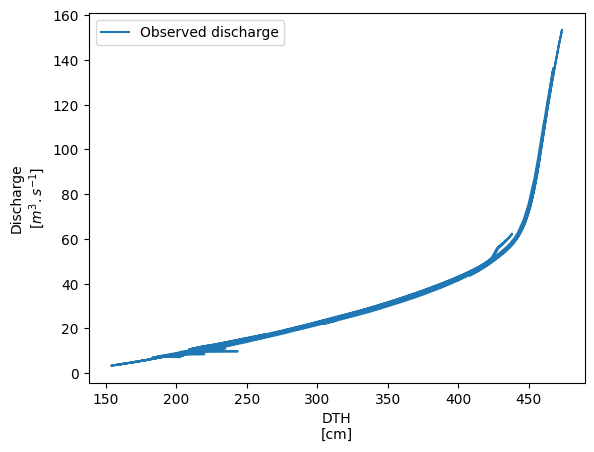

In [3]:
# takes 1:23 to run

# a1, a2, c1, c2, n1, n2, hlow, hhigh = calculate_rating_curve()
# print(f"a1: {a1}, a2: {a2}, c1: {c1}, c2: {c2}, n1: {n1}, n2: {n2}, hlow: {hlow}, hhigh: {hhigh}")

# Calculate simulated discharge
observed_discharge = get_diso()
hs = get_h()

plt.plot(hs, observed_discharge, label="Observed discharge")
plt.xlabel('DTH\n[cm]')
plt.ylabel('Discharge\n[$m^3.s^{-1}$]')
plt.legend()
plt.show()


/var/folders/0n/bb4_kwsn3n5c5_7n_mgl2n540000gn/T/ipykernel_51649/646591838.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(x_labels.index, rotation=45)  # Rotate the tick labels


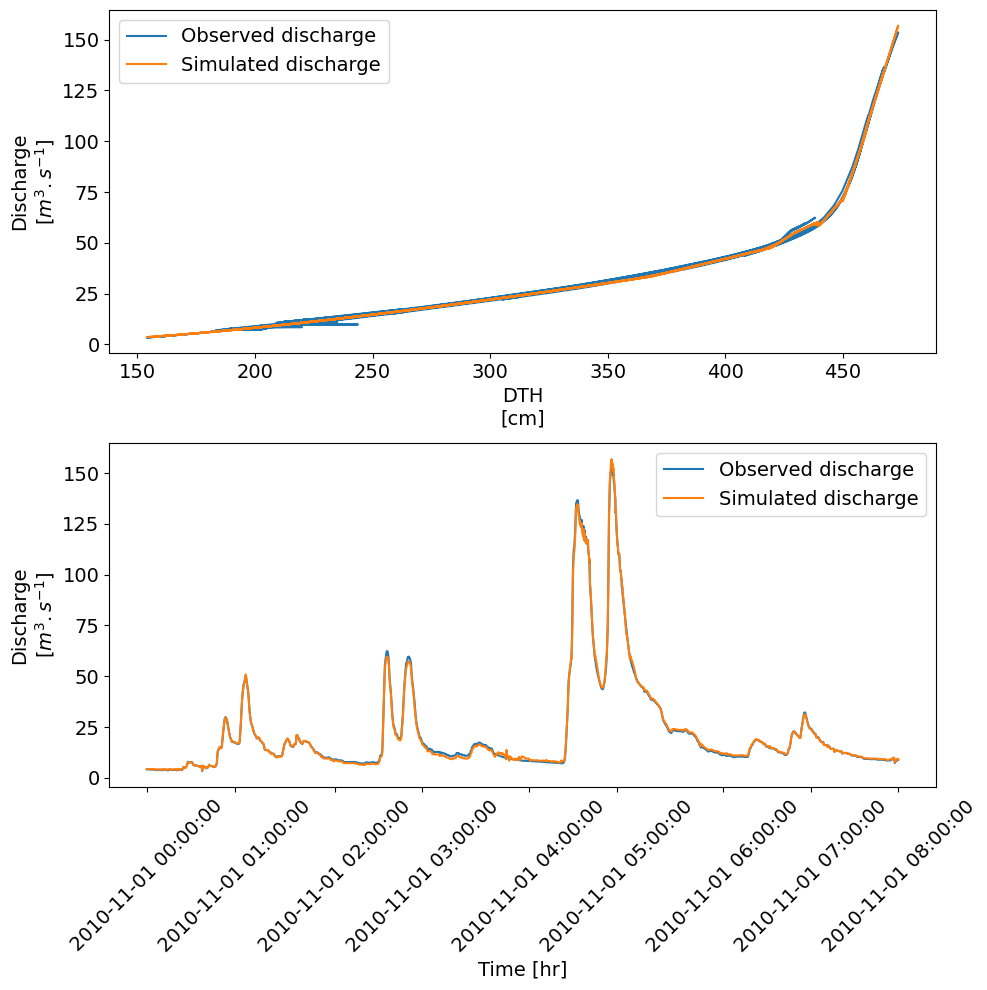

In [4]:
simulated_discharge = calculate_simulated_discharge_original_h(rating_curve_params)
labelsize = 14

fig, axs = plt.subplots(2, 1, figsize=(10, 10))

axs[0].plot(hs, observed_discharge, label="Observed discharge")
axs[0].plot(hs, simulated_discharge, label="Simulated discharge")
axs[0].set_xlabel('DTH\n[cm]', fontsize=labelsize)
axs[0].set_ylabel('Discharge\n[$m^3.s^{-1}$]', fontsize=labelsize)
axs[0].legend(fontsize=labelsize)

main_dir = Path(r'/Users/elias/Desktop/HWS24/MMUQ Seminar/time_series__24163005')
os.chdir(main_dir)
x_labels = pd.read_csv(r'time_series___24163005.csv', sep=';', index_col=0)
x_labels.index = pd.to_datetime(x_labels.index, format='%Y-%m-%d-%H')

axs[1].plot(x_labels.index, observed_discharge, label="Observed discharge")
axs[1].plot(x_labels.index, simulated_discharge, label="Simulated discharge")
axs[1].set_xticklabels(x_labels.index, rotation=45)  # Rotate the tick labels
axs[1].set_xlabel('Time [hr]', fontsize=labelsize)
axs[1].set_ylabel('Discharge\n[$m^3.s^{-1}$]', fontsize=labelsize)
axs[1].legend(fontsize=labelsize)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    ax.tick_params(axis='both', which='minor', labelsize=labelsize)

plt.tight_layout()
plt.show()

/var/folders/0n/bb4_kwsn3n5c5_7n_mgl2n540000gn/T/ipykernel_51649/2657022181.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(x_labels.index, rotation=45)


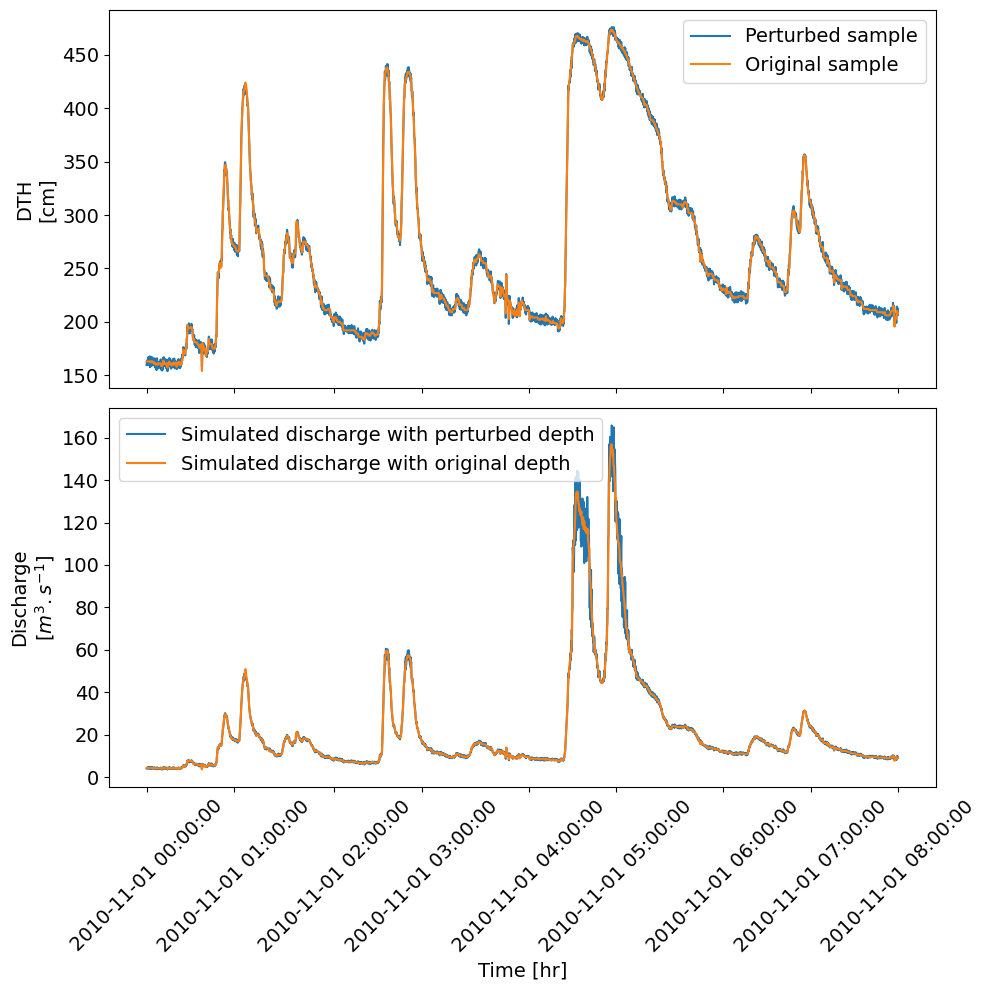

In [5]:

labelsize = 14

fig, axs = plt.subplots(2, 1, figsize=(10, 10))
# Plot one perturbed sample and the original one
axs[0].plot(x_labels.index, perturbed_hs[0], label="Perturbed sample")
axs[0].plot(x_labels.index, hs, label="Original sample")
axs[0].set_xticklabels([])
axs[0].set_ylabel('DTH\n[cm]', fontsize=labelsize)
axs[0].legend(fontsize=labelsize)

# plot resulting simulated discharge
axs[1].plot(x_labels.index, calculate_simulated_discharge_perturbed_h(rating_curve_params, perturbed_hs[0]), label="Simulated discharge with perturbed depth")
axs[1].plot(x_labels.index, calculate_simulated_discharge_perturbed_h(rating_curve_params, hs), label="Simulated discharge with original depth")
axs[1].set_xticklabels(x_labels.index, rotation=45)
axs[1].set_xlabel('Time [hr]', fontsize=labelsize)
axs[1].set_ylabel('Discharge\n[$m^3.s^{-1}$]', fontsize=labelsize)
axs[1].legend(fontsize=labelsize)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    ax.tick_params(axis='both', which='minor', labelsize=labelsize)

plt.tight_layout()
plt.show()

Model runtime: 3.58E-04 seconds.


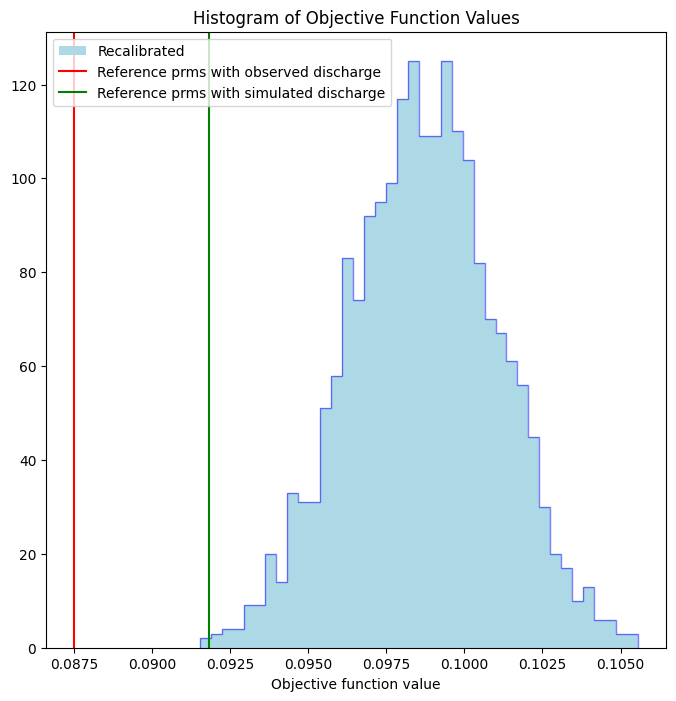

Number of improved cases w.r.t. simulated discharge: 2


In [11]:
# Plot Histogram of objective function values

# Calculate reference ofv for simulated discharge with original depth
diso_simulated_orig_h = calculate_simulated_discharge_original_h(rating_curve_params)
modl_objt = setup_object_with_data()
modl_objt.set_parameters(ref_params)
modl_objt.set_optimization_flag(0)
# Run the model for the given inputs, constants and parameters.
modl_objt.run_model()
diss = modl_objt.get_discharge()
ref_obj_value_sim_discharge = 1 - NSE(sim_dis=diss, obs_dis=diso_simulated_orig_h)

fig = plt.figure(figsize=(8, 8))
# sns.kdeplot(recalib_obj_values, color='blue', label='recalibrated')
plt.hist(recalib_obj_values, bins=40, density=False, histtype='stepfilled', color='lightblue', label='Recalibrated')
plt.hist(recalib_obj_values, bins=40, density=False, histtype='step', color='blue', alpha=0.5)
locs, _ = plt.yticks() 
plt.axvline(ref_obj_value, color='red', label='Reference prms with observed discharge')
plt.axvline(ref_obj_value_sim_discharge, color='green', label='Reference prms with simulated discharge')
plt.xlabel('Objective function value')
plt.legend()
plt.title('Histogram of Objective Function Values')
plt.show()
print(f"Number of improved cases w.r.t. simulated discharge: {np.sum(recalib_obj_values < ref_obj_value_sim_discharge)}")

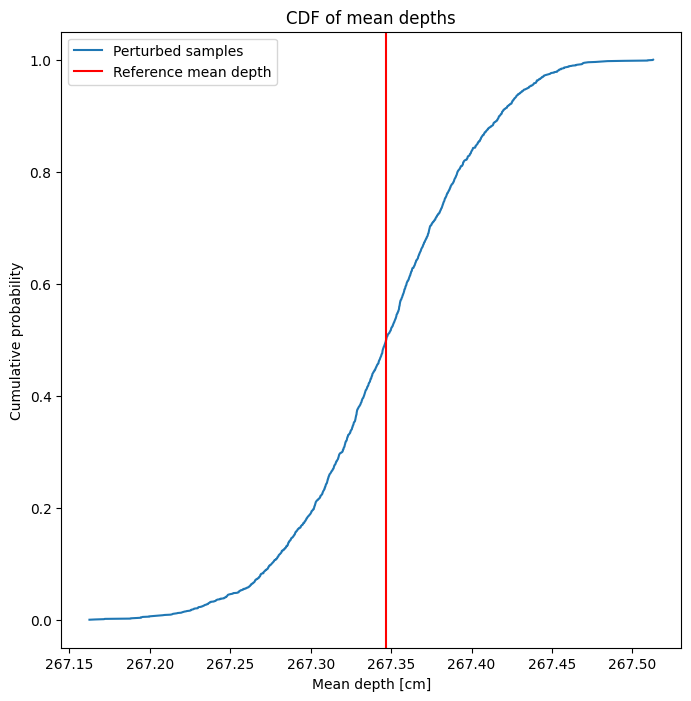

In [12]:
# Plot CDF of mean depths
means_perturbed_hs = np.mean(perturbed_hs, axis=1)
means_perturbed_hs_sorted = np.sort(means_perturbed_hs)
means_perturbed_hs_cumulative = np.arange(1, len(means_perturbed_hs_sorted) + 1) / len(means_perturbed_hs_sorted)

fig = plt.figure(figsize=(8, 8))
plt.plot(means_perturbed_hs_sorted,
                means_perturbed_hs_cumulative,
                label='Perturbed samples')
# Straight line for reference mean depth
plt.axvline(np.mean(hs), color='red', label='Reference mean depth')
plt.xlabel('Mean depth [cm]')
plt.ylabel('Cumulative probability')
plt.legend()
plt.title('CDF of mean depths')
plt.show()

/var/folders/0n/bb4_kwsn3n5c5_7n_mgl2n540000gn/T/ipykernel_51649/4205364293.py:8: RuntimeWarning: invalid value encountered in divide
  params_i_normalized = (recalib_params[:, i] - param_bounds[0]) / (param_bounds[1] - param_bounds[0])
/var/folders/0n/bb4_kwsn3n5c5_7n_mgl2n540000gn/T/ipykernel_51649/4205364293.py:12: RuntimeWarning: invalid value encountered in scalar divide
  ax.axvline((ref_params[i] - param_bounds[0]) / (param_bounds[1] - param_bounds[0]), color='red', label='reference')


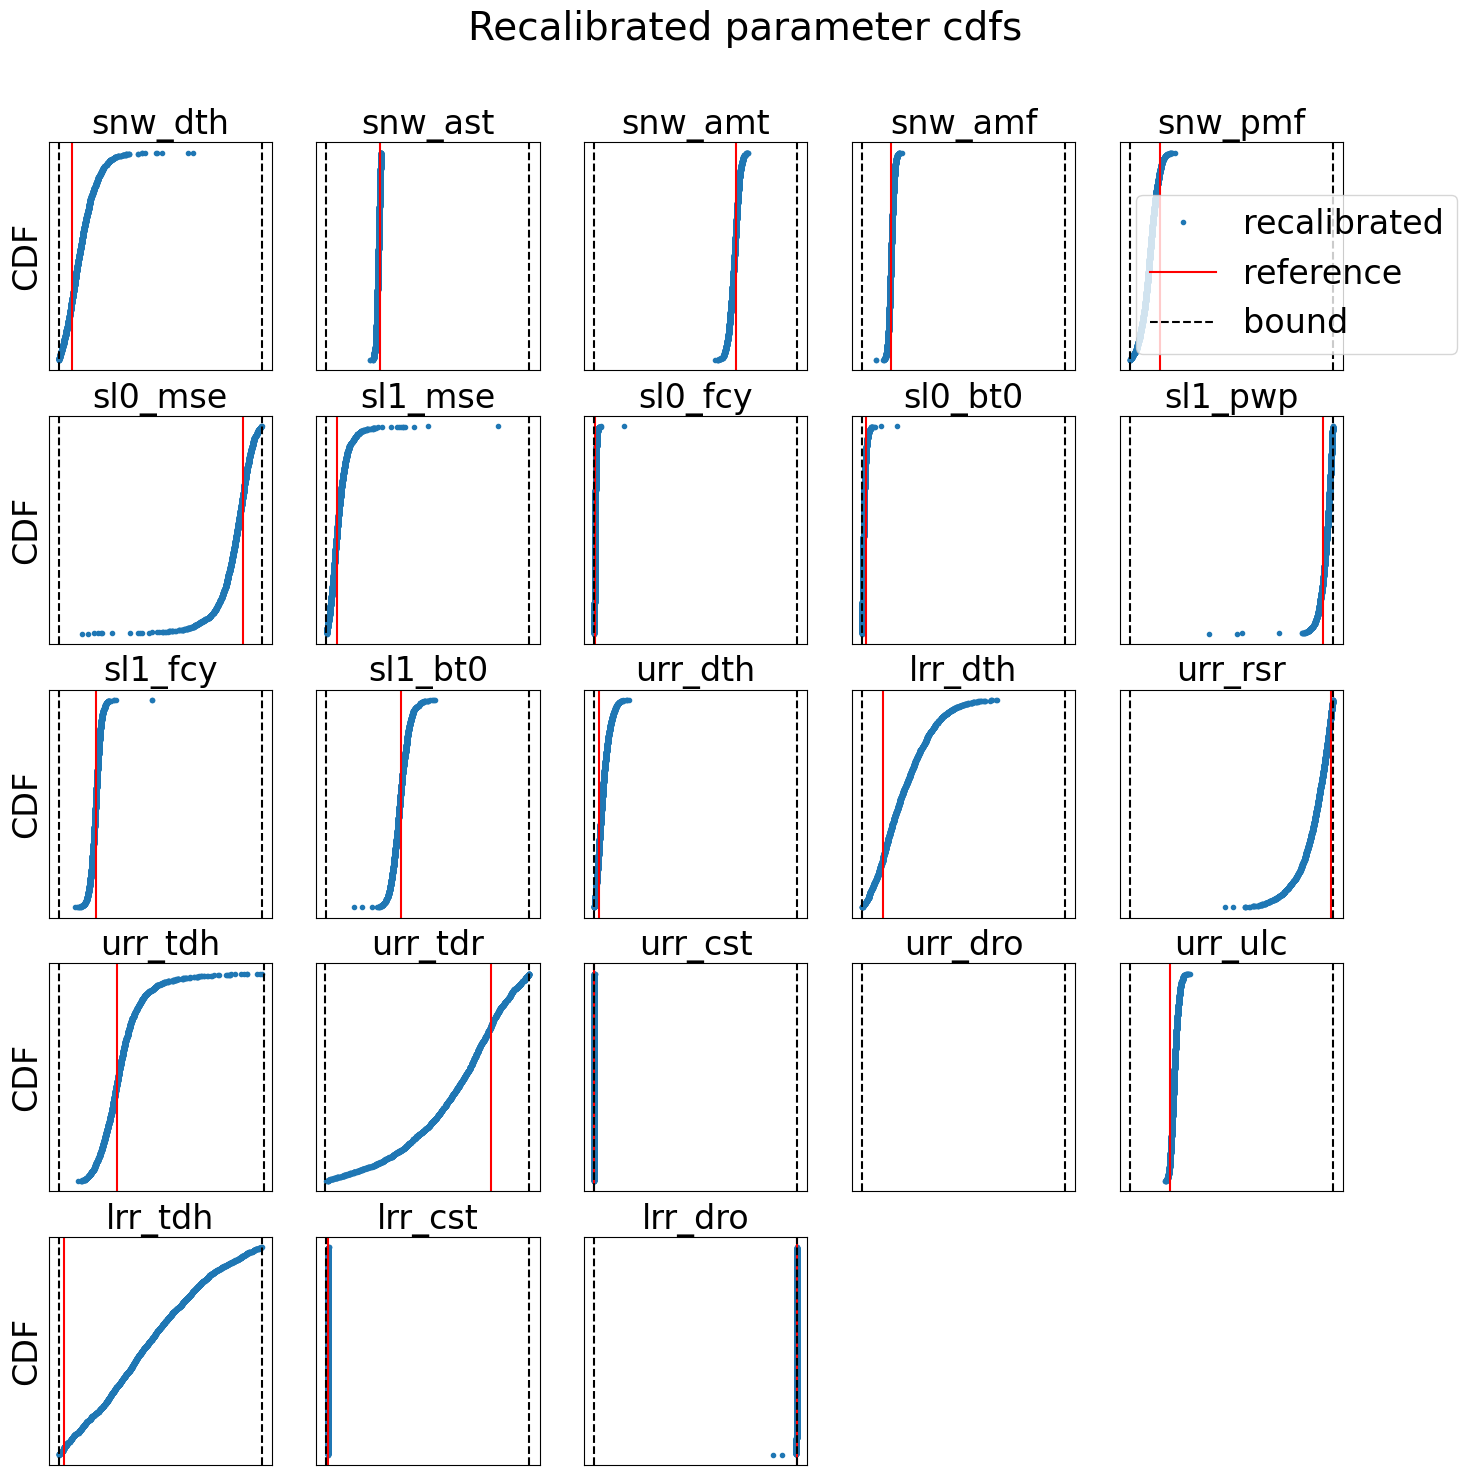

In [8]:


fig, axes = plt.subplots(5, 5, figsize=(15, 15))
fig.suptitle("Recalibrated parameter cdfs", fontsize=28)

for i, ax in enumerate(axes.flat):
    if i < recalib_params.shape[1]:
        param_name = list(bounds.keys())[i]
        param_bounds = bounds[param_name]
        params_i_normalized = (recalib_params[:, i] - param_bounds[0]) / (param_bounds[1] - param_bounds[0])
        params_i_normalized_sorted = np.sort(params_i_normalized)
        params_i_normalized_cumulative = np.arange(1, len(params_i_normalized_sorted) + 1) / len(params_i_normalized_sorted)
        ax.plot(params_i_normalized_sorted, params_i_normalized_cumulative, marker='.', linestyle='none', label='recalibrated')
        ax.axvline((ref_params[i] - param_bounds[0]) / (param_bounds[1] - param_bounds[0]), color='red', label='reference')
        ax.axvline(0, color='black', linestyle='--', label='bound')
        ax.axvline(1, color='black', linestyle='--')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f'{param_name}', fontsize=24)
        if i % 5 == 0:
            ax.set_ylabel('CDF', fontsize=24)
        if i == 4:
            ax.legend(fontsize=24)
    else:
        ax.axis('off')  # Turn off the axis if there's no data for this subplot

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust rect to make room for the suptitle
plt.subplots_adjust(hspace=0.2, wspace=0.2)  # Adjust hspace and wspace as needed
plt.show()


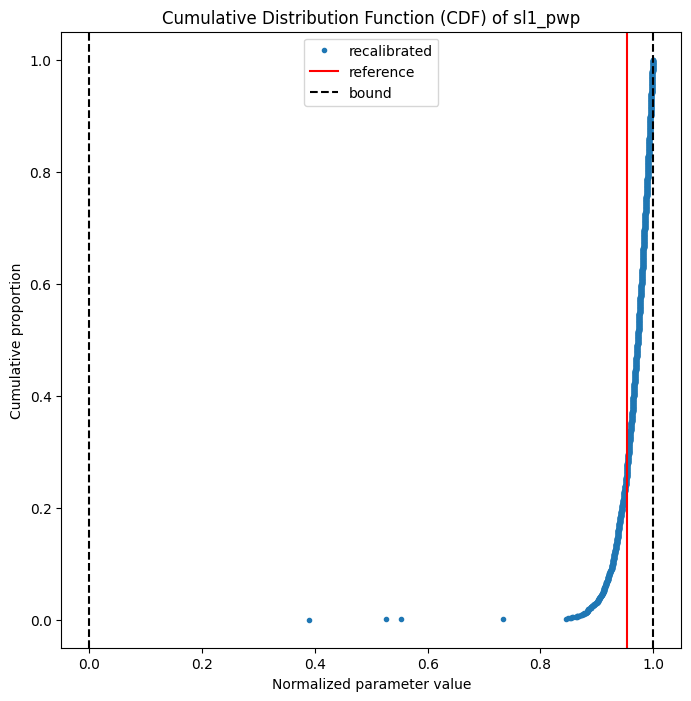

In [9]:
# Plot one specific parameter in a big figure
param_name = 'sl1_pwp'
param_index = list(bounds.keys()).index(param_name)
param_bounds = bounds[param_name]
params_i_normalized = (recalib_params[:, param_index] - param_bounds[0]) / (param_bounds[1] - param_bounds[0])
params_i_normalized_sorted = np.sort(params_i_normalized)
params_i_normalized_cumulative = np.arange(1, len(params_i_normalized_sorted) + 1) / len(params_i_normalized_sorted)

fig = plt.figure(figsize=(8, 8))
plt.plot(params_i_normalized_sorted, params_i_normalized_cumulative, marker='.', linestyle='none', label='recalibrated')

plt.axvline((ref_params[param_index] - param_bounds[0]) / (param_bounds[1] - param_bounds[0]), color='red', label='reference')
plt.axvline(0, color='black', linestyle='--', label='bound')
plt.axvline(1, color='black', linestyle='--')
plt.xlabel('Normalized parameter value')
plt.ylabel('Cumulative proportion')
plt.title(f'Cumulative Distribution Function (CDF) of {param_name}')
plt.legend()
plt.show()

Model runtime: 3.27E-04 seconds.
Model runtime: 3.22E-04 seconds.
Model runtime: 3.22E-04 seconds.
Model runtime: 3.08E-04 seconds.
Model runtime: 3.20E-04 seconds.
Model runtime: 3.23E-04 seconds.
Model runtime: 3.23E-04 seconds.
Model runtime: 3.07E-04 seconds.
Model runtime: 3.19E-04 seconds.
Model runtime: 3.07E-04 seconds.
Model runtime: 3.18E-04 seconds.
Model runtime: 3.23E-04 seconds.
Model runtime: 3.40E-04 seconds.
Model runtime: 3.17E-04 seconds.
Model runtime: 3.52E-04 seconds.
Model runtime: 3.21E-04 seconds.
Model runtime: 3.20E-04 seconds.
Model runtime: 3.10E-04 seconds.
Model runtime: 3.15E-04 seconds.
Model runtime: 3.83E-04 seconds.
Model runtime: 3.06E-04 seconds.
Model runtime: 3.06E-04 seconds.
Model runtime: 3.20E-04 seconds.
Model runtime: 3.18E-04 seconds.
Model runtime: 3.09E-04 seconds.
Model runtime: 3.40E-04 seconds.
Model runtime: 3.15E-04 seconds.
Model runtime: 3.06E-04 seconds.
Model runtime: 3.06E-04 seconds.
Model runtime: 3.16E-04 seconds.
Model runt

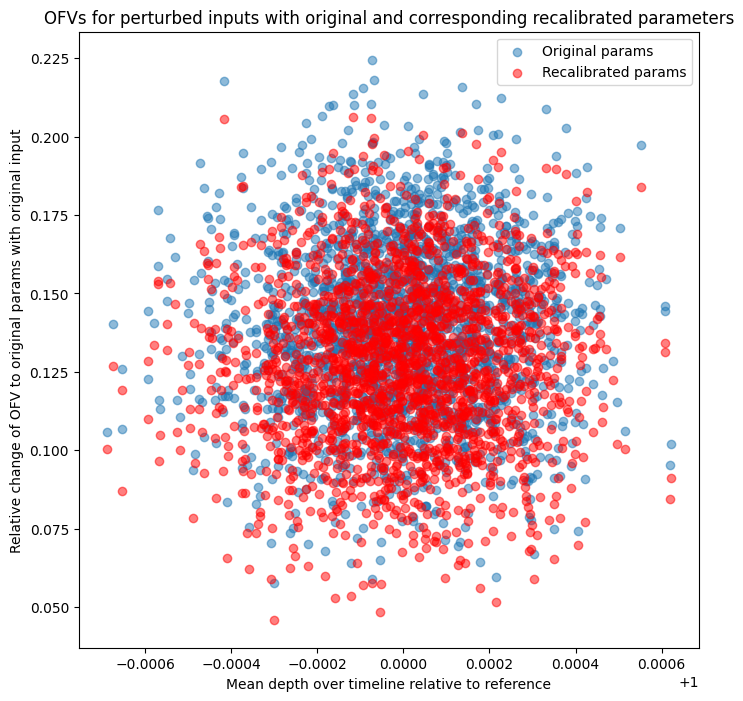

Number of improved cases: 2000 of 2000


In [10]:
# Exercise: Scatter OFV

# OFVs perturbed inputs for recalibrated parameters: recalib_obj_values

# OFVs perturbed inputs for original opt. parameters

# order results by mean depth
mean_hs = np.mean(perturbed_hs, axis=1)
sorted_indices = np.argsort(mean_hs)
perturbed_hs = perturbed_hs[sorted_indices]
mean_hs = mean_hs[sorted_indices]
recalib_obj_values = recalib_obj_values[sorted_indices]

ref_h = get_h() # reference preciptiation
ref_mean_h = np.mean(ref_h)

obj_values_pert_input_orig_params = []
for i in range(perturbed_hs.shape[0]):
    modl_objt = setup_object_with_data()
    diso = calculate_simulated_discharge_perturbed_h(rating_curve_params, perturbed_hs[i])
    obj_values_pert_input_orig_params.append(objective_function(ref_params, diso, modl_objt, efficieny_metric=NSE))

relative_change_orig_params = (obj_values_pert_input_orig_params - ref_obj_value) / ref_obj_value
relative_change_recab_params = (recalib_obj_values - ref_obj_value) / ref_obj_value

fig = plt.figure(figsize=(8, 8))
plt.scatter(mean_hs/ref_mean_h, relative_change_orig_params, alpha=0.5, label='Original params')
plt.scatter(mean_hs/ref_mean_h, relative_change_recab_params, alpha=0.5, color='red', label='Recalibrated params')
plt.legend()
plt.xlabel('Mean depth over timeline relative to reference')
plt.ylabel('Relative change of OFV to original params with original input')
plt.title('OFVs for perturbed inputs with original and corresponding recalibrated parameters')
plt.show()

# Number of improved cases
print(f'Number of improved cases: {np.sum(relative_change_recab_params <= relative_change_orig_params)} of {len(relative_change_orig_params)}')